In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
import random
from PIL import Image, ImageOps

In [60]:
imgs_folders = 'imgs'
imgs = os.listdir(imgs_folders)
imgs.remove(".DS_Store") if ".DS_Store" in imgs else None

In [5]:
imgs = ['IMG_3005.JPG','IMG_3004.JPG']
imgs = ['shapes.png']

In [7]:
out_folder = "R_B_shifted"
if not os.path.isdir(out_folder):
    os.mkdir(out_folder)

In [9]:
def shift_BR(image_path, shift_ratio=0.1):
    # Load the image (assume it's BGR)
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the path.")

    height, width = img.shape[:2]
    shift_px = int(width * shift_ratio)

    # Split the channels
    b, g, r = cv2.split(img)

    # Define shifting matrices
    M_left = np.float32([[1, 0, -shift_px], [0, 1, 0]])
    M_right = np.float32([[1, 0, shift_px], [0, 1, 0]])

    # Shift blue to the left
    b_shifted = cv2.warpAffine(b, M_left, (width, height))

    # Shift red to the right
    r_shifted = cv2.warpAffine(r, M_right, (width, height))

    # Combine channels back (G is unchanged)
    result = cv2.merge((b_shifted, g, r_shifted))

    return result

In [51]:
def shift_CM(image_path, shift_ratio=0.1):
    # Load the image (assume it's BGR)
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the path.")

    height, width = img.shape[:2]
    shift_px = int(width * shift_ratio)

    # Split the channels
    b, g, r = cv2.split(img)

    # Define shifting matrices
    M_left = np.float32([[1, 0, -shift_px], [0, 1, 0]])
    M_right = np.float32([[1, 0, shift_px], [0, 1, 0]])

    # Shift blue to the left
    b_shifted = cv2.warpAffine(b, M_left, (width, height))
    g_shifted = cv2.warpAffine(g, M_left, (width, height))
    c_shifted = b_shifted + g_shifted
    # Shift red to the right
    r_shifted = cv2.warpAffine(r, M_right, (width, height))
    g_shifted = cv2.warpAffine(g, M_left, (width, height))
    m_shifted = g_shifted  + r_shifted
    # Combine channels back (G is unchanged)
    result = cv2.merge((c_shifted, g, m_shifted))

    return result

In [ ]:
for i in imgs:
    ipath = os.path.join(imgs_folders,i)
    opath = os.path.join(out_folder, "R_B_shifted" + i)
    if not os.path.isfile(opath):
        rbshifted = shift_BR(ipath,.03)
        cv2.imwrite(opath,rbshifted)

imgs/lupita.jpeg


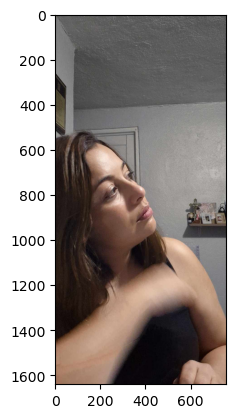

In [62]:
#imgs_folder = "imgs_plants"
imgs_folder = "imgs"
f = "shapes.png"
f = "lupita.jpeg"
i = os.path.join(imgs_folder,f)
print(i)
img = cv2.imread(i)
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [64]:

imgs_folders = "imgs"
out_folder = "R_B_shifted"
ipath = os.path.join(imgs_folders,f)
opath = os.path.join(out_folder, "R_B_shifted" + f)

In [66]:
opath

'R_B_shifted/R_B_shiftedlupita.jpeg'

In [68]:
rbshifted = shift_BR(ipath,.04)
rbshifted_rgb = cv2.cvtColor(rbshifted,cv2.COLOR_BGR2RGB)

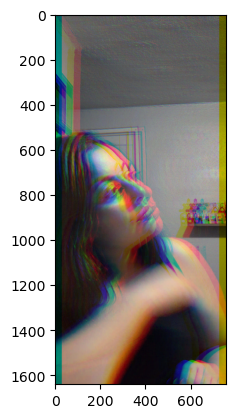

In [70]:
plt.imshow(rbshifted_rgb)

In [72]:

if not os.path.isfile(opath):
    rbshifted = shift_BR(ipath,.04)
    cv2.imwrite(opath,rbshifted)

In [74]:
opath

'R_B_shifted/R_B_shiftedlupita.jpeg'

In [53]:

cmshifted = shift_CM(ipath,.04)
cmshifted_rgb = cv2.cvtColor(cmshifted,cv2.COLOR_BGR2RGB)

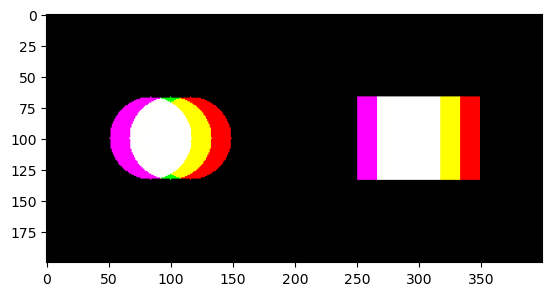

In [55]:
plt.imshow(cmshifted_rgb)

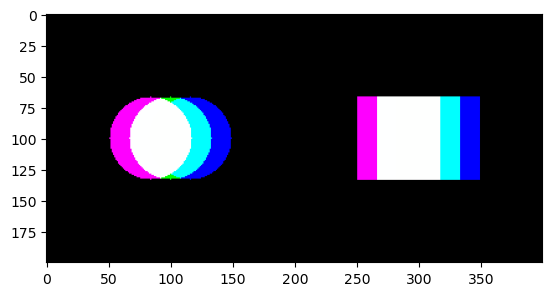

In [57]:
plt.imshow(cmshifted)